In [ ]:
import pandas as pd
from datasets import load_dataset, DatasetDict

/Users/sjviray814/Documents/CS 4641/ChessPuzzleEvaluator/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
ds = load_dataset("Lichess/chess-puzzles")

Generating train split: 100%|██████████| 5751400/5751400 [00:01<00:00, 3018285.29 examples/s]


In [ ]:
DATASET_SIZE = 1000000
subset = ds["train"].shuffle(seed=42).select(range(DATASET_SIZE))

In [ ]:
subset.features

{'PuzzleId': Value('large_string'),
 'GameId': Value('string'),
 'FEN': Value('large_string'),
 'Moves': Value('large_string'),
 'Rating': Value('uint16'),
 'RatingDeviation': Value('uint16'),
 'Popularity': Value('int8'),
 'NbPlays': Value('uint32'),
 'Themes': List(Value('string')),
 'OpeningTags': List(Value('string'))}

In [ ]:
subset[0]

{'PuzzleId': '1ttUB',
 'GameId': 'XL6z9NwE#19',
 'FEN': 'r2qkb1r/pppb1ppp/4p3/8/1n6/1PN2Q2/1PPPNPPP/R1BK3R w kq - 1 10',
 'Moves': 'f3b7 d7c6 b7c6 b4c6',
 'Rating': 1344,
 'RatingDeviation': 76,
 'Popularity': 90,
 'NbPlays': 1728,
 'Themes': ['crushing', 'master', 'opening', 'short', 'trappedPiece'],
 'OpeningTags': ['Alekhine_Defense',
  'Alekhine_Defense_Scandinavian_Variation']}

In [ ]:
len(subset)

1000000

In [ ]:
# train test split
train_test = subset.train_test_split(test_size=0.2, seed=42)
test_val = train_test["test"].train_test_split(test_size=0.5, seed=42)
ds_dict = DatasetDict({
    "train": train_test["train"],
    "val": test_val["train"],
    "test": test_val["test"],
})

In [ ]:
print("train samples", len(ds_dict["train"]), "val samples", len(ds_dict["val"]), "test samples", len(ds_dict["test"]))

train samples 800000 val samples 100000 test samples 100000


# Dataset Statistics

Statistical Description of the Data:
              Rating     Popularity        NbPlays
count  800000.000000  800000.000000  800000.000000
mean     1479.616791      86.099876    1663.602799
std       547.255640      14.237391    4475.335118
min       399.000000     -65.000000       0.000000
25%      1050.000000      83.000000     111.000000
50%      1429.000000      90.000000     358.000000
75%      1886.000000      94.000000    1237.000000
max      3247.000000     100.000000  230211.000000


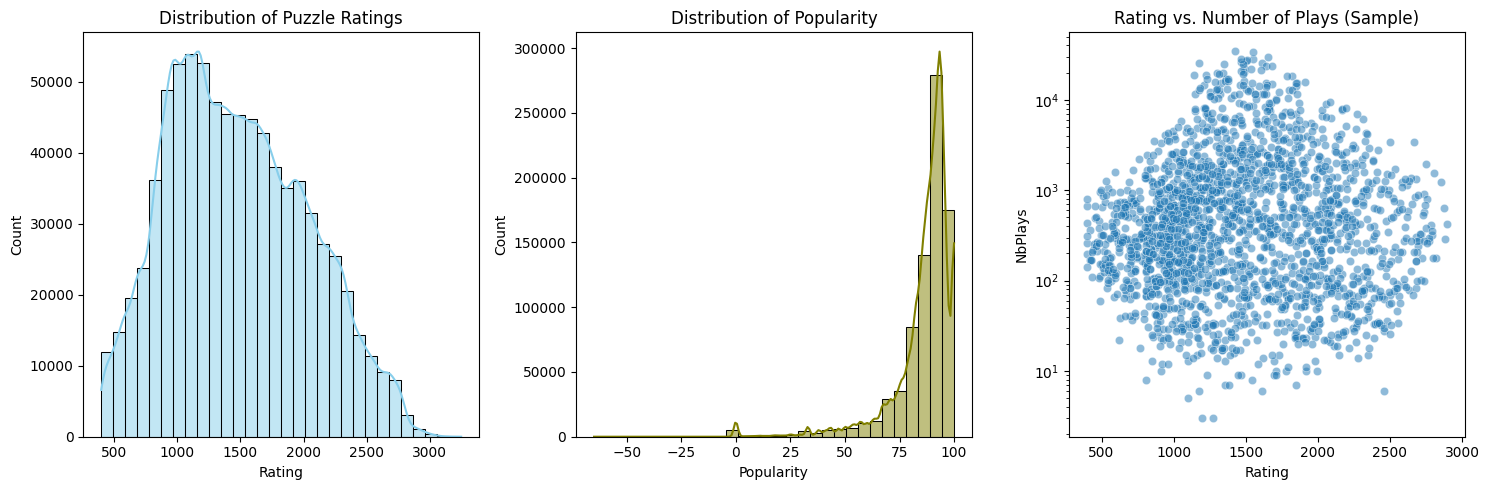

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

stats_df = ds_dict["train"].to_pandas()[["Rating", "Popularity", "NbPlays"]]
print("Statistical Description of the Data:")
print(stats_df.describe())

plt.figure(figsize=(15, 5))

# Rating Distribution
plt.subplot(1, 3, 1)
sns.histplot(stats_df['Rating'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Puzzle Ratings')

# Popularity Distribution
plt.subplot(1, 3, 2)
sns.histplot(stats_df['Popularity'], bins=30, kde=True, color='olive')
plt.title('Distribution of Popularity')

# Number of Plays vs Rating
plt.subplot(1, 3, 3)
sns.scatterplot(data=stats_df.sample(2000), x='Rating', y='NbPlays', alpha=0.5)
plt.yscale('log') # Log scale since plays are skewed
plt.title('Rating vs. Number of Plays (Sample)')

plt.tight_layout()
plt.show()

/var/folders/bj/lwmh4hr11hlb23t722219vl40000gn/T/ipykernel_74961/1129732368.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=themes_df, x='Count', y='Theme', palette='viridis')


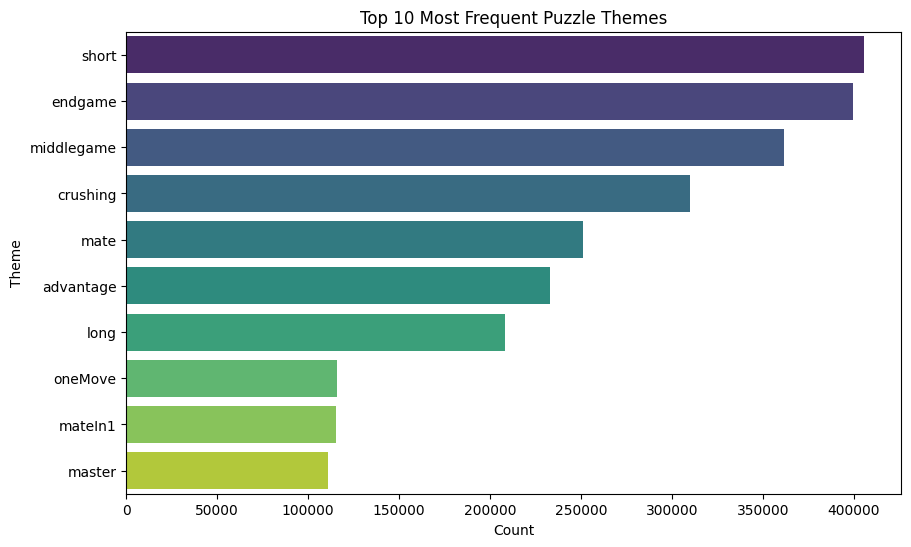

In [ ]:
from collections import Counter

all_themes = [theme for themes_list in ds_dict["train"]["Themes"] for theme in themes_list]
theme_counts = Counter(all_themes).most_common(10)

# Display top 10 themes
themes_df = pd.DataFrame(theme_counts, columns=['Theme', 'Count'])
plt.figure(figsize=(10, 6))
sns.barplot(data=themes_df, x='Count', y='Theme', palette='viridis')
plt.title('Top 10 Most Frequent Puzzle Themes')
plt.show()

/var/folders/bj/lwmh4hr11hlb23t722219vl40000gn/T/ipykernel_74961/857703667.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_plays, x='TotalPlays', y='Theme', palette='magma')


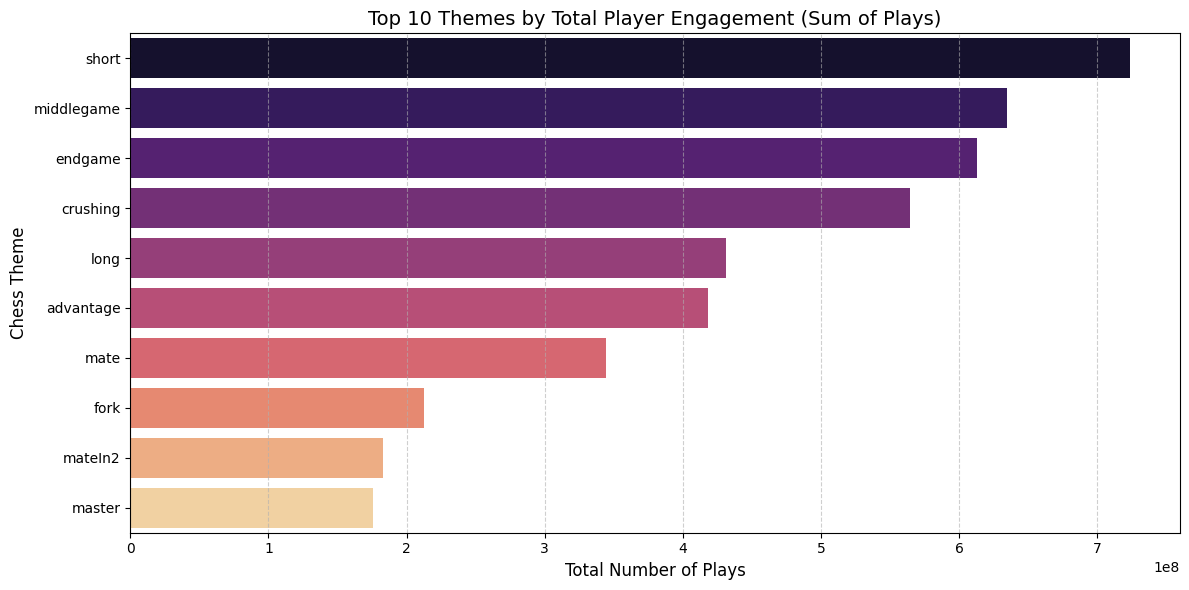

In [ ]:
from collections import defaultdict

theme_plays_map = defaultdict(int)

for themes, plays in zip(ds_dict["train"]["Themes"], ds_dict["train"]["NbPlays"]):
    for theme in themes:
        theme_plays_map[theme] += plays

theme_plays_df = pd.DataFrame(
    list(theme_plays_map.items()), 
    columns=['Theme', 'TotalPlays']
).sort_values(by='TotalPlays', ascending=False)

top_10_plays = theme_plays_df.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_plays, x='TotalPlays', y='Theme', palette='magma')

plt.title('Top 10 Themes by Total Plays', fontsize=14)
plt.xlabel('Total Number of Plays', fontsize=12)
plt.ylabel('Chess Theme', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Map: 100%|██████████| 800000/800000 [00:48<00:00, 16498.88 examples/s]
/var/folders/bj/lwmh4hr11hlb23t722219vl40000gn/T/ipykernel_74961/563955464.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ds_dict["train"].to_pandas(), x='MoveCount', y='Popularity', palette='coolwarm')


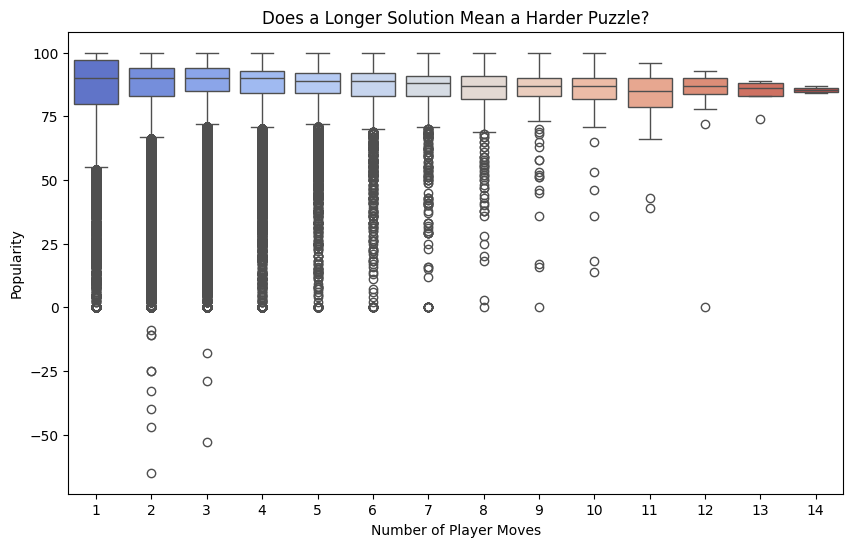

In [ ]:
ds_dict["train"] = ds_dict["train"].map(lambda x: {"MoveCount": len(x["Moves"].split()) // 2})

plt.figure(figsize=(10, 6))
sns.boxplot(data=ds_dict["train"].to_pandas(), x='MoveCount', y='Popularity', palette='coolwarm')
plt.title('Does a Longer Solution Mean a Better Puzzle?')
plt.xlabel('Number of Player Moves')
plt.ylabel('Popularity')
plt.show()

Map: 100%|██████████| 800000/800000 [00:52<00:00, 15173.22 examples/s]


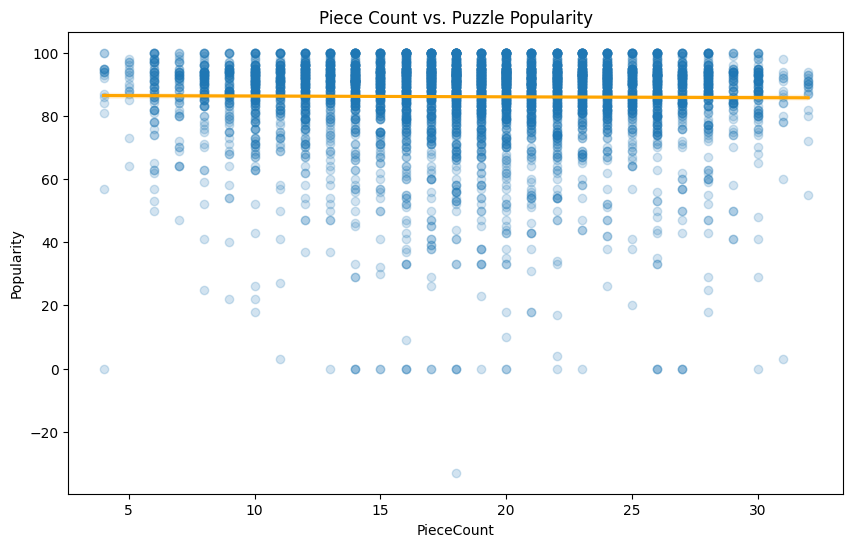

In [ ]:
def count_pieces(fen):
    board = fen.split()[0]
    return sum(1 for char in board if char.isalpha())

ds_dict["train"] = ds_dict["train"].map(lambda x: {"PieceCount": count_pieces(x["FEN"])})

plt.figure(figsize=(10, 6))
sns.regplot(data=ds_dict["train"].to_pandas().sample(5000), 
            x='PieceCount', y='Popularity', scatter_kws={'alpha':0.2}, line_kws={'color':'orange'})
plt.title('Piece Count vs. Puzzle Popularity')
plt.show()

<Axes: xlabel='Rating', ylabel='Popularity'>

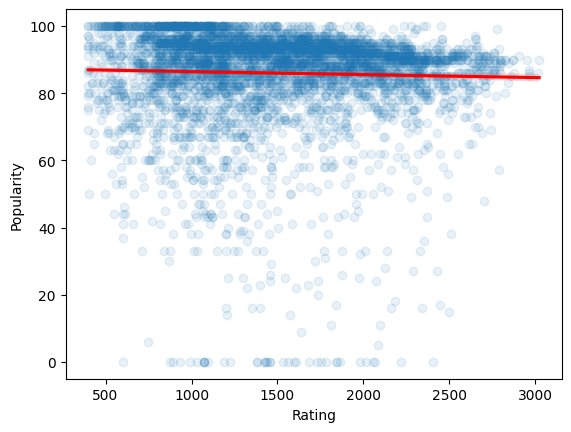

In [ ]:
sns.regplot(stats_df.sample(5000), x='Rating', y='Popularity', 
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})